In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib



In [3]:
# Charger les données (ville en index)
df = pd.read_csv('villes.csv', sep=';', index_col=0)

# 1. Préparation des données
labels = df.index.values
X = df.values

# 2. Standardisation des données (important avant PCA et KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Application de l'ACP (PCA) pour réduire à 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [4]:
# 4. Application de KMeans pour obtenir 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
clustering = kmeans.labels_


Clustering terminé, graphique sauvegardé dans clusters_villes.png


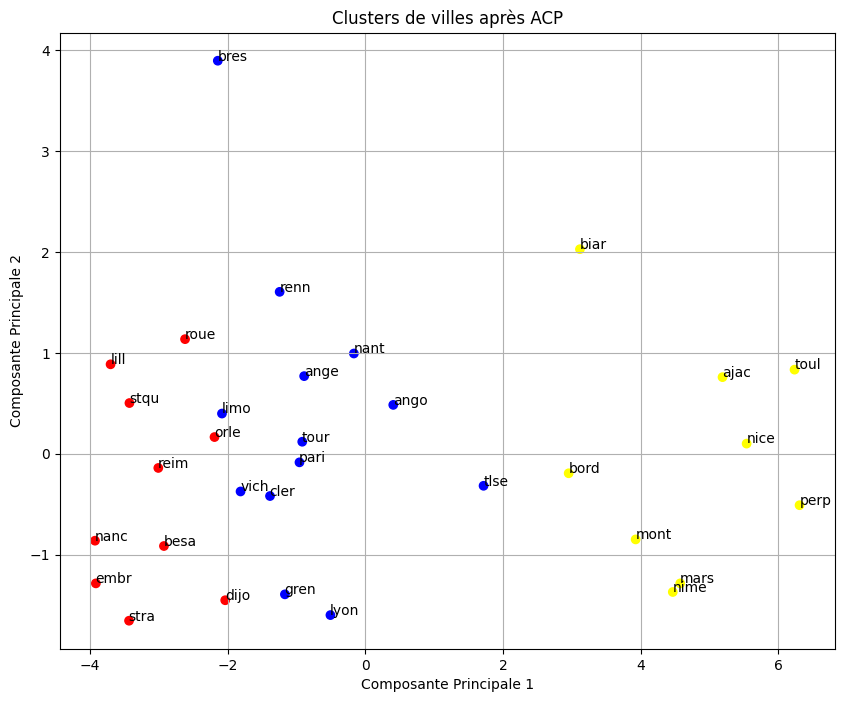

In [5]:
# 5. Visualisation (Code fourni mis à jour pour 3 couleurs de clusters)
colors = ['red', 'yellow', 'blue'] # 3 clusters = 3 couleurs
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clustering, 
            cmap=matplotlib.colors.ListedColormap(colors))

for label, x, y in zip(labels, X_pca[:, 0], X_pca[:, 1]):
    plt.annotate(label, xy=(x, y), xytext=(-0.2, 0.2), textcoords='offset points')

plt.title('Clusters de villes après ACP')
plt.xlabel('Composante Principale 1')
plt.ylabel('Composante Principale 2')
plt.grid(True)
plt.savefig('clusters_villes.png')
print("Clustering terminé, graphique sauvegardé dans clusters_villes.png")
